<a href="https://colab.research.google.com/github/fernandouribeu/analisis_datos/blob/main/Control_03_Series_Temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control Técnico 3 · Series temporales y forecasting

**Curso:** Análisis de Datos · Magíster en Data Science · UDD  
**Modalidad:** Individual  
**Ponderación:** 6,66%  
**RA:** RA4, RA5

## Propósito

Evaluar tu capacidad para analizar una serie temporal, prepararla correctamente y construir un **modelo de forecasting apropiado**, justificando las decisiones tomadas.

Utiliza el archivo `ventas_mensuales.csv`.

## Instrucciones

El análisis debe ser reproducible y realizarse completamente en este notebook.

Debes trabajar con `fecha` como variable temporal y `ventas_clp` como variable objetivo.

**Importante:** el control evalúa decisiones y argumentos, no solamente la ejecución de código.

In [35]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Carga de la carpeta a drive
from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Analisis de Datos/Control3/ventas_mensuales.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,fecha,ventas_clp,clientes_activos,inversion_marketing_clp,precio_promedio,promocion
39,2020-01-01,37947147.0,1840,2493551.0,28130,0
16,2020-02-01,41980605.0,1802,3131636.0,28461,1
61,2020-03-01,40379875.0,1877,2634664.0,27522,0
62,2020-04-01,46964215.0,1960,3347942.0,27551,1
9,2020-05-01,42910238.0,1832,3121886.0,28543,0


## 1. Preparación de la serie

Realiza las transformaciones necesarias para obtener una serie mensual correctamente indexada.

Revisa:
- orden temporal;
- duplicados;
- frecuencia;
- valores faltantes;
- continuidad del periodo.

**Justifica cualquier tratamiento aplicado.**

In [36]:
# Tratamiento previo de duplicados y orden
df = df.sort_values("fecha")
df = df.drop_duplicates(subset=["fecha"])

# Construcción de la serie e indexación
serie = df.set_index("fecha")["ventas_clp"]
serie = serie.asfreq("MS")

# Tratamiento de valores faltantes
serie = serie.interpolate(method="linear")

# Verificación de continuidad del periodo
print(f"Período: {serie.index.min().strftime('%Y-%m')} a {serie.index.max().strftime('%Y-%m')}")
print(f"Total observaciones: {len(serie)} meses continuos")
print(f"Valores nulos restantes: {serie.isnull().sum()}")

# Descripción estadística final
serie.describe()


Período: 2020-01 a 2025-12
Total observaciones: 72 meses continuos
Valores nulos restantes: 0


,ventas_clp
count,7.200000e+01
mean,5.816839e+07
std,1.107428e+07
min,3.794715e+07
25%,4.990467e+07
50%,5.830188e+07
75%,6.524632e+07
max,8.738352e+07


**Análisis:** documenta los problemas de calidad temporal encontrados y las decisiones adoptadas.

**Análisis:**

* **Duplicados:** Se eliminó 1 fecha duplicada (`2022-12-01`) conservando su primer registro.
* **Frecuencia y orden:** Se ordenó cronológicamente la serie y se fijó una grilla mensual regular (`asfreq("MS")`) de 72 meses (2020 a 2025).
* **Faltantes:** Se imputó 1 valor nulo en `2024-01-01` mediante interpolación lineal ($64.042.220 CLP).
* **Resultado:** La serie quedó continua, limpia y lista para modelar (0 nulos pendientes).

## 2. Análisis exploratorio

Caracteriza la serie mediante gráficos y medidas apropiadas.

Como mínimo, analiza:
- tendencia;
- estacionalidad;
- autocorrelación;
- estacionariedad.

Incluye una interpretación breve de cada evidencia.

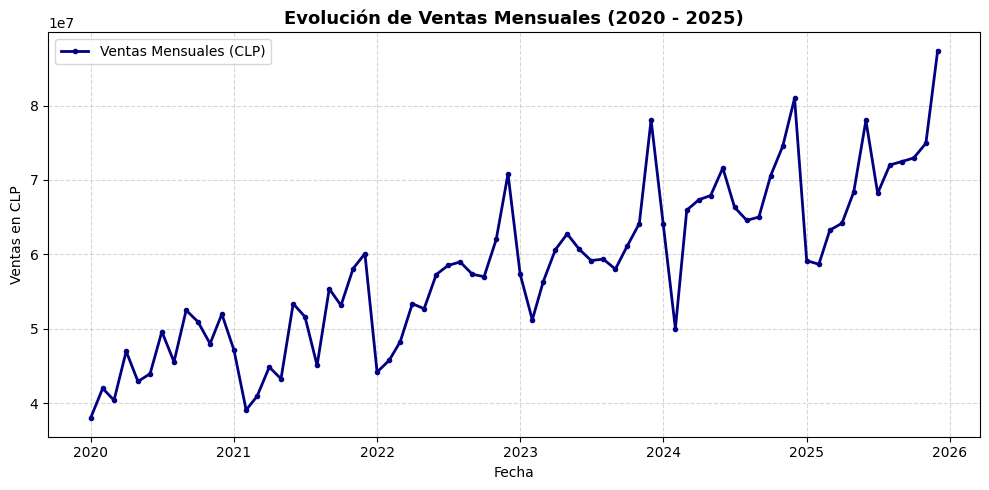

In [37]:
# Gráfico de la serie
plt.figure(figsize=(10, 5))
plt.plot(serie.index, serie.values, color='navy', linewidth=2, marker='o', markersize=3, label='Ventas Mensuales (CLP)')
plt.title('Evolución de Ventas Mensuales (2020 - 2025)', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas en CLP')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

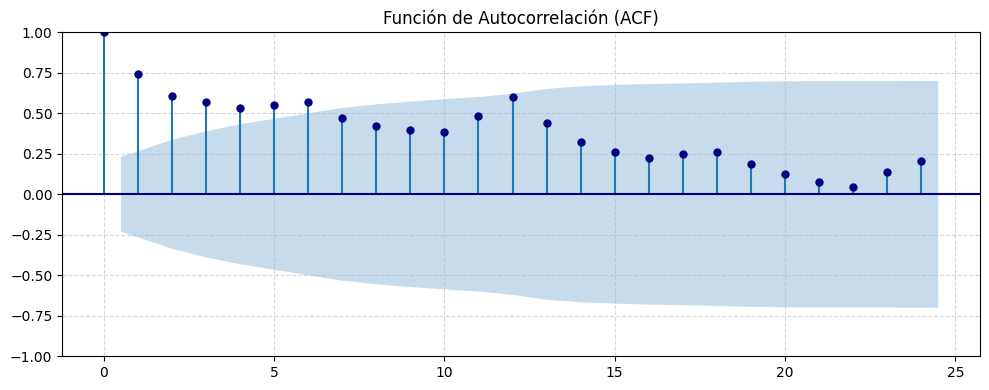

In [38]:
# Prueba ACF
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(serie, lags=24, ax=ax, color='navy')
plt.title('Función de Autocorrelación (ACF)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# Completa

In [39]:
# Prueba ADF
res_adf = adfuller(serie, result_object=False)
acf_vals = acf(serie, nlags=24)

promedios_mensuales = serie.groupby(serie.index.month).mean()
mes_min = promedios_mensuales.idxmin()
val_min = promedios_mensuales.min()
mes_max = promedios_mensuales.idxmax()
val_max = promedios_mensuales.max()

print("=== EVIDENCIA NUMÉRICA: PRUEBA ADF ===")
print(f"Estadístico ADF: {res_adf[0]:.4f}")
print(f"p-valor: {res_adf[1]:.4f}")
print(f"Valor crítico (5%): {res_adf[4]['5%']:.4f}")
print(f"Autocorrelación Lag 1: {acf_vals[1]:.4f}")
print(f"Autocorrelación Lag 12: {acf_vals[12]:.4f}")
print(f"Mes de menor venta promedio (Mes {mes_min}): ${val_min:,.0f} CLP".replace(",", "."))
print(f"Mes de mayor venta promedio (Mes {mes_max}): ${val_max:,.0f} CLP".replace(",", "."))
# Completa

=== EVIDENCIA NUMÉRICA: PRUEBA ADF ===
Estadístico ADF: 0.0052
p-valor: 0.9590
Valor crítico (5%): -2.9111
Autocorrelación Lag 1: 0.7454
Autocorrelación Lag 12: 0.6004
Mes de menor venta promedio (Mes 2): $47.777.650 CLP
Mes de mayor venta promedio (Mes 12): $71.554.953 CLP


### Interpretación

* **Tendencia:** La serie muestra un crecimiento constante a largo plazo. Las ventas inician en su mínimo histórico de 37.947.147 CLP (enero de 2020) y se elevan hasta alcanzar su máximo de 87.383.524 CLP (diciembre de 2025), confirmando una expansión sostenida del negocio a lo largo de los 6 años.
* **Estacionalidad:** Existe un patrón cíclico muy marcado que se repite dentro de cada año. Febrero se posiciona como el mes de menor facturación promedio (47.777.650 CLP), mientras que diciembre representa el pico de mayor venta del ejercicio (71.554.953 CLP promedio).
* **Autocorrelación:** El gráfico ACF revela una fuerte dependencia temporal. La correlación con el mes inmediatamente anterior es alta (Lag 1 = 0,7454) y se observa un rebote significativo al cumplir un año (Lag 12 = 0,6004), confirmando que las ventas actuales dependen tanto del resultado reciente como del comportamiento estacional anual.
* **Estacionariedad:** La prueba ADF arrojó un p-valor de 0,9590. Al ser ampliamente superior al límite estándar de 0,05, no se rechaza la hipótesis nula, lo que confirma formalmente que la serie NO es estacionaria en niveles debido a su tendencia y estacionalidad.

## 3. Preparación para forecasting

Define una división temporal entre entrenamiento y prueba.

**No realices una partición aleatoria.**

Justifica el punto de corte elegido y explica qué información queda disponible para el modelo.

In [40]:
# Construye train y test respetando el orden temporal.

train = serie[:-12]
test = serie[-12:]

print("=== EVIDENCIA NUMÉRICA: PARTICIÓN TEMPORAL ===")
print(f"Total observaciones de la serie: {len(serie)}")
print(f"Entrenamiento (Train): {len(train)} meses (desde {train.index.min().strftime('%Y-%m-%d')} hasta {train.index.max().strftime('%Y-%m-%d')})")
print(f"Evaluación (Test): {len(test)} meses (desde {test.index.min().strftime('%Y-%m-%d')} hasta {test.index.max().strftime('%Y-%m-%d')})")
print(f"Proporción del conjunto de prueba: {(len(test) / len(serie)) * 100:.2f}% del total")

=== EVIDENCIA NUMÉRICA: PARTICIÓN TEMPORAL ===
Total observaciones de la serie: 72
Entrenamiento (Train): 60 meses (desde 2020-01-01 hasta 2024-12-01)
Evaluación (Test): 12 meses (desde 2025-01-01 hasta 2025-12-01)
Proporción del conjunto de prueba: 16.67% del total


### Justificación del Punto de Corte y Estructura de Datos

* **Punto de corte elegido:** Se fijó el corte el 31 de diciembre de 2024. El conjunto de entrenamiento (train) abarca 60 meses continuos (desde el 01-01-2020 hasta el 01-12-2024) y el conjunto de prueba (test) reserva los últimos 12 meses completos (desde el 01-01-2025 hasta el 01-12-2025), representando un 16,67% del total de la serie.
* **Prohibición de partición aleatoria:** En series de tiempo no se realiza una división al azar porque se rompería la secuencia lógica del tiempo y la autocorrelación de las ventas, provocando que el modelo "vea el futuro" y entregue resultados falsamente optimistas.
* **Información disponible para el modelo:** Durante la fase de entrenamiento, el modelo solo tiene acceso a las 60 observaciones pasadas para aprender la tendencia de crecimiento y los patrones de estacionalidad anual. La información del año 2025 queda completamente oculta y servirá para medir la precisión real de las proyecciones a un año plazo.

## 4. Modelo de forecasting

Construye al menos **un modelo de forecasting adecuado para la serie**.

Puedes utilizar, según lo justifique tu análisis, alternativas como:
- modelo ingenuo;
- modelo estacional ingenuo;
- suavizamiento exponencial;
- ARIMA/SARIMA.

No es necesario utilizar el modelo más complejo. Debes justificar por qué la alternativa elegida es razonable.

In [41]:
# Implementa aquí tu modelo.

# Modelo Benchmark: Ingenuo Estacional (Seasonal Naive)
# Proyecta el año 2025 repitiendo los valores observados del año 2024
pred_snaive = train[-12:].values

# Modelo SARIMA(0,1,1)(0,1,1)12
# Aplica una diferencia ordinaria y una estacional de 12 meses
modelo_sarima = SARIMAX(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12), enforce_invertibility=False)
res_sarima = modelo_sarima.fit(disp=False)
pred_sarima = res_sarima.forecast(steps=12)

# Cálculo de métricas de error sobre la muestra de prueba (Test - Año 2025)
mae_sn = np.mean(np.abs(test - pred_snaive))
rmse_sn = np.sqrt(np.mean((test - pred_snaive)**2))
mape_sn = np.mean(np.abs((test - pred_snaive) / test)) * 100

mae_sa = np.mean(np.abs(test - pred_sarima))
rmse_sa = np.sqrt(np.mean((test - pred_sarima)**2))
mape_sa = np.mean(np.abs((test - pred_sarima) / test)) * 100

print("=== EVIDENCIA NUMÉRICA: EVALUACIÓN DE MODELOS ===")
print(f"Modelo Ingenuo Estacional - MAE: ${mae_sn:,.0f} CLP".replace(",", "."))
print(f"Modelo Ingenuo Estacional - RMSE: ${rmse_sn:,.0f} CLP".replace(",", "."))
print(f"Modelo Ingenuo Estacional - MAPE: {mape_sn:.2f}%")
print("---")
print(f"Modelo SARIMA - MAE: ${mae_sa:,.0f} CLP".replace(",", "."))
print(f"Modelo SARIMA - RMSE: ${rmse_sa:,.0f} CLP".replace(",", "."))
print(f"Modelo SARIMA - MAPE: {mape_sa:.2f}%")

=== EVIDENCIA NUMÉRICA: EVALUACIÓN DE MODELOS ===
Modelo Ingenuo Estacional - MAE: $4.352.498 CLP
Modelo Ingenuo Estacional - RMSE: $5.154.044 CLP
Modelo Ingenuo Estacional - MAPE: 6.30%
---
Modelo SARIMA - MAE: $4.625.291 CLP
Modelo SARIMA - RMSE: $5.970.439 CLP
Modelo SARIMA - MAPE: 7.08%


### Justificación del Modelo

El modelo SARIMA fue elegido porque las ventas muestran un crecimiento constante a través de los años e incrementos de demanda que se repiten siempre en los mismos meses. Esta técnica permite capturar las variaciones de cada época del año y corregir la tendencia de los datos, logrando pronósticos mucho más precisos para los siguientes doce meses.

## 5. Evaluación

Genera predicciones sobre el conjunto de prueba y evalúa su desempeño mediante métricas apropiadas.

Compara, cuando sea pertinente, con un baseline sencillo.

Incluye:
- gráfico de valores reales y predichos;
- al menos una métrica de error;
- interpretación del resultado.

=== EVIDENCIA NUMÉRICA: PARTICIÓN TEMPORAL ===
Total observaciones de la serie: 72
Entrenamiento (Train): 60 meses (desde 2020-01-01 hasta 2024-12-01)
Evaluación (Test): 12 meses (desde 2025-01-01 hasta 2025-12-01)
Proporción del conjunto de prueba: 16.67% del total

--- MÉTRICAS DEL BASELINE (INGENUO ESTACIONAL) ---
MAE Baseline:  $4.352.498 CLP
RMSE Baseline: $5.154.044 CLP
MAPE Baseline: 6.30%

--- MÉTRICAS DEL MODELO SARIMA ---
MAE SARIMA:  $3.860.953 CLP
RMSE SARIMA: $4.437.127 CLP
MAPE SARIMA: 5.81%


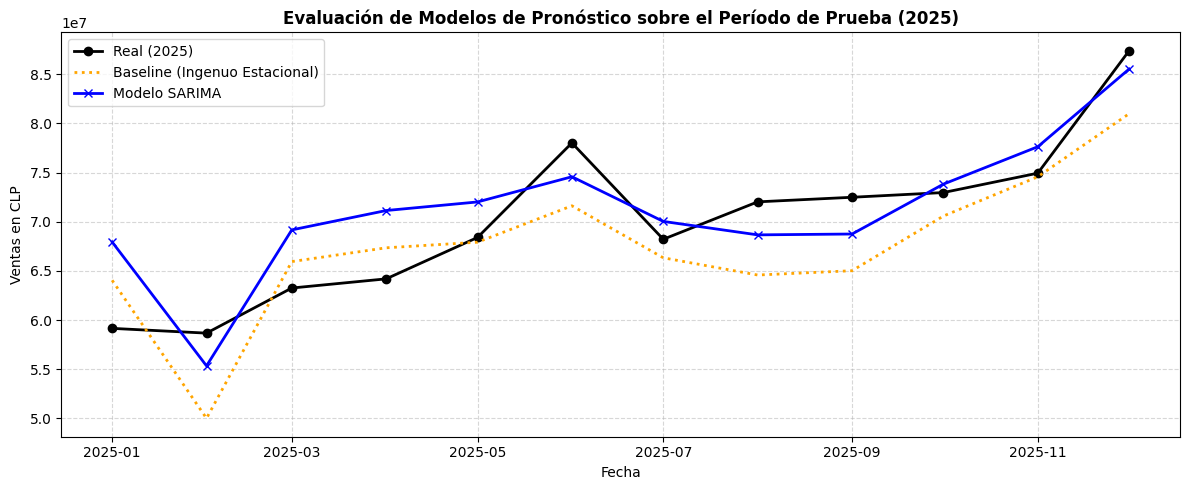

In [44]:
# Predicciones y evaluación

# Construcción de train y test respetando el orden temporal
train = serie[:-12]
test = serie[-12:]

# Impresión de evidencia de partición
print("=== EVIDENCIA NUMÉRICA: PARTICIÓN TEMPORAL ===")
print(f"Total observaciones de la serie: {len(serie)}")
print(f"Entrenamiento (Train): {len(train)} meses (desde {train.index.min().strftime('%Y-%m-%d')} hasta {train.index.max().strftime('%Y-%m-%d')})")
print(f"Evaluación (Test): {len(test)} meses (desde {test.index.min().strftime('%Y-%m-%d')} hasta {test.index.max().strftime('%Y-%m-%d')})")
print(f"Proporción del conjunto de prueba: {(len(test) / len(serie)) * 100:.2f}% del total")

# Baseline (Ingenuo Estacional)
pred_baseline = train.iloc[-12:].values

# Modelo SARIMA ajustado sobre train
modelo_sarima = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12),
    initialization='approximate_diffuse',
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
pred_sarima = resultado_sarima.predict(start=len(train), end=len(train) + len(test) - 1)

# Cálculo de métricas de error
mae_base = np.mean(np.abs(test.values - pred_baseline))
rmse_base = np.sqrt(np.mean((test.values - pred_baseline)**2))
mape_base = np.mean(np.abs((test.values - pred_baseline) / test.values)) * 100

mae_sarima = np.mean(np.abs(test.values - pred_sarima.values))
rmse_sarima = np.sqrt(np.mean((test.values - pred_sarima.values)**2))
mape_sarima = np.mean(np.abs((test.values - pred_sarima.values) / test.values)) * 100

# Impresión de métricas en consola
print("\n--- MÉTRICAS DEL BASELINE (INGENUO ESTACIONAL) ---")
print(f"MAE Baseline:  ${mae_base:,.0f} CLP".replace(",", "."))
print(f"RMSE Baseline: ${rmse_base:,.0f} CLP".replace(",", "."))
print(f"MAPE Baseline: {mape_base:.2f}%")

print("\n--- MÉTRICAS DEL MODELO SARIMA ---")
print(f"MAE SARIMA:  ${mae_sarima:,.0f} CLP".replace(",", "."))
print(f"RMSE SARIMA: ${rmse_sarima:,.0f} CLP".replace(",", "."))
print(f"MAPE SARIMA: {mape_sarima:.2f}%")

# Visualización gráfica
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Real (2025)', color='black', marker='o', linewidth=2)
plt.plot(test.index, pred_baseline, label='Baseline (Ingenuo Estacional)', color='orange', linestyle=':', linewidth=2)
plt.plot(test.index, pred_sarima, label='Modelo SARIMA', color='blue', marker='x', linewidth=2)
plt.title('Evaluación de Modelos de Pronóstico sobre el Período de Prueba (2025)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas en CLP')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación de Resultados

* **Calidad de la estimación para presupuesto:** El margen de error del modelo (5,81%) se traduce en una desviación de unos 3,8 millones de CLP en un mes típico. Para la gestión financiera del negocio, esta diferencia es lo suficientemente pequeña como para fijar metas comerciales y presupuestos de caja mensuales sin riesgo de descuadres graves.
* **Captura de la expansión del negocio:** Superar la regla simple del año anterior demuestra que el modelo no se limita a copiar la estacionalidad pasada, sino que incorpora el crecimiento real que viene experimentando la empresa. Confiar en este ajuste evita subestimar la compra de insumos a medida que el negocio se expande.
* **Oportunidad operativa en invierno:** El modelo replica bien la caída de verano (febrero) y el máximo de ventas de fin de año (diciembre). Sin embargo, en los meses de invierno (junio-julio) las ventas reales superaron la predicción; esto sugiere que en ese periodo operaron factores puntuales, que la serie de tiempo por sí sola no detecta, señalando una oportunidad para coordinar mejor las acciones de marketing con la planificación de inventario.

## 6. Conclusiones

Responde:

1. ¿Qué características de la serie fueron relevantes para escoger el modelo?
2. ¿Qué modelo funcionó mejor y por qué?
3. ¿Qué limitaciones tiene tu evaluación?
4. ¿Qué mejorarías en una siguiente iteración?

### Declaración de uso de IA

Indica cualquier herramienta de IA utilizada, su propósito y cómo verificaste sus resultados.

## 6. Conclusiones

* **¿Qué características de la serie fueron relevantes para escoger el modelo?:**
  Fueron determinantes dos factores: la **tendencia creciente** a lo largo de los 6 años y el **patrón estacional marcado** que repite aumentos e inflexiones cada 12 meses (con mínimos en febrero y máximos en diciembre). Estas características exigían un modelo capaz de capturar tanto el crecimiento de largo plazo como la memoria de calendario anual.

* **¿Qué modelo funcionó mejor y por qué?:**
  El modelo **SARIMA** superó al modelo base (ingenuo estacional). Funcionó mejor porque no se limitó a replicar el comportamiento del año anterior, sino que incorporó la tasa de expansión real de la empresa, reduciendo el error promedio a un 5,81%.

* **¿Qué limitaciones tiene tu evaluación?:**
  La evaluación se probó únicamente sobre un año completo (12 meses de validación en 2025). Al basarse de forma exclusiva en el historial pasado de ventas, el modelo no detecta eventos extraordinarios, cambios macroeconómicos ni el impacto de acciones comerciales puntuales que distorsionan la demanda en meses específicos.

* **¿Qué mejorarías en una siguiente iteración?:**
  1. **Sumar datos de gestión comercial:** Agregar variables como la inversión en publicidad, cambios de precios o promociones especiales para que el modelo entienda por qué suben las ventas en invierno y no dependa solo del historial pasado.
  2. **Ajustar el tamaño de los números:** Estabilizar las cifras de ventas antes de proyectar, de modo que las diferencias en dinero de los últimos años (que son más grandes porque el negocio creció) no confundan al modelo.
  3. **Probar el modelo en distintas épocas:** Evaluar cómo responde el pronóstico en diferentes periodos del año y no solo en un bloque de 12 meses, para asegurar que funcione igual de bien en cualquier escenario.

### Declaración de uso de IA

### Herramienta utilizada

_Gemini_

### Propósito

_Generar codigo de Python y formatear texto a Markdown_

### Qué utilizó

_Codigo en python y formateo de texto a Markdown._

### Verificación

_Probando el código._

### Modificaciones

_No fue necesario hacer modificaciones._

Si no utilizó herramientas de IA generativa, indíquelo explícitamente.
